In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("/content/netflix_titles.csv")

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [4]:
print("Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDataset Info:")
print(df.info())

Shape: (8807, 12)

Data Types:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982

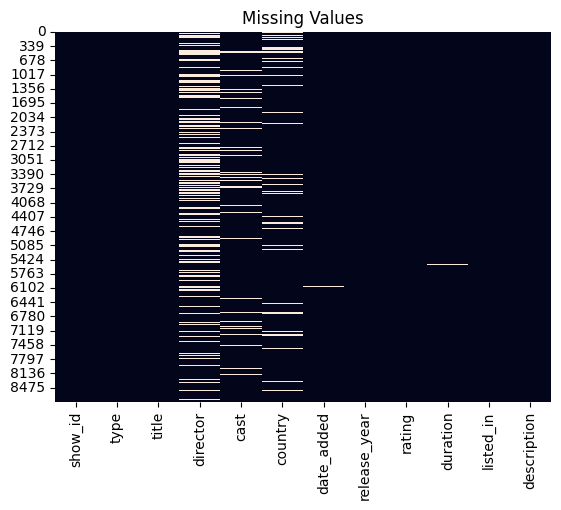

In [5]:
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

In [6]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Not Available')
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])
df['date_added'] = df['date_added'].fillna(df['date_added'].mode()[0])

In [7]:
print(df.isnull().sum())

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
dtype: int64


In [9]:
le = LabelEncoder()

df['type_encoded'] = le.fit_transform(df['type'])
df['rating_encoded'] = le.fit_transform(df['rating'])

print(df[['type', 'type_encoded']].head())

      type  type_encoded
0    Movie             0
1  TV Show             1
2  TV Show             1
3  TV Show             1
4  TV Show             1


In [12]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print(numerical_columns)

Index(['release_year', 'type_encoded', 'rating_encoded'], dtype='object')


In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water          Unknown   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans          Unknown   
4      s5  TV Show           Kota Factory          Unknown   

                                                cast        country  \
0                                      Not Available  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...  United States   
3                                      Not Available  United States   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021      0.659930  PG-13     90 min   
1  September 24, 2021      0.773324  TV-MA  2 Seasons   
2  September 24, 2021      0.

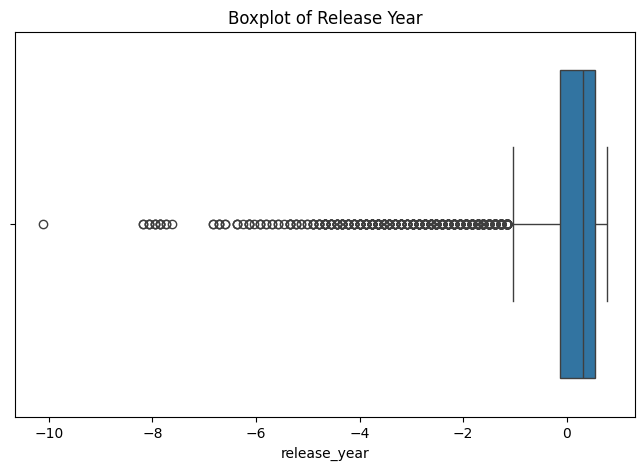

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
num_cols = ['release_year']

plt.figure(figsize=(8,5))
sns.boxplot(x=df['release_year'])
plt.title('Boxplot of Release Year')
plt.show()

In [17]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)

IQR = Q3 - Q1

df_clean = df[~((df[num_cols] < (Q1 - 1.5 * IQR)) |
                (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", df.shape)
print("After Removing Outliers:", df_clean.shape)

Original Shape: (8807, 14)
After Removing Outliers: (8024, 14)


In [18]:
print(df_clean.info())

print(df_clean.describe())

<class 'pandas.core.frame.DataFrame'>
Index: 8024 entries, 0 to 8806
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   show_id         8024 non-null   object 
 1   type            8024 non-null   object 
 2   title           8024 non-null   object 
 3   director        8024 non-null   object 
 4   cast            8024 non-null   object 
 5   country         8024 non-null   object 
 6   date_added      8024 non-null   object 
 7   release_year    8024 non-null   float64
 8   rating          8024 non-null   object 
 9   duration        8021 non-null   object 
 10  listed_in       8024 non-null   object 
 11  description     8024 non-null   object 
 12  type_encoded    8024 non-null   float64
 13  rating_encoded  8024 non-null   float64
dtypes: float64(3), object(11)
memory usage: 940.3+ KB
None
       release_year  type_encoded  rating_encoded
count   8024.000000   8024.000000     8024.000000
mean       0.25212

In [19]:
df_clean.to_csv("cleaned_netflix_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
